# Cognitive Load Prediction — EDA & Preprocessing
### *Branch A · Eye-Tracking Cognitive Load Classification*

---

| Field | Details |
|-------|---------|
| **Project** | Non-Invasive Cognitive Load and Student Engagement Detection |
| **Author** | Yasini Mandara Karunanayake |
| **RGU ID** | 2313473  **IIT ID** 20221151 |
| **Dataset** | [Kaggle Student Engagement Dataset (EEG)](https://www.kaggle.com/datasets/ziya07/student-engagement-dataset-using-eeg) |


---

## 📋 Notebook Overview

This notebook implements **Stage 1 of Branch A** of the multimodal pipeline.
It loads the Kaggle Student Engagement Dataset, conducts EDA on the four retained eye-tracking features, builds the feature matrix (EEG columns excluded), performs a stratified 80/20 split, applies SMOTE, fits a StandardScaler, and exports all splits to CSV files for model training.

| Step | Description |
|------|-------------|
| 1 | Library imports |
| 2 | Dataset loading & inspection |
| 3 | Eye-metric distributions by engagement label |
| 4 | Pearson correlation analysis |
| 5 | Feature matrix construction (eye metrics only) |
| 6 | Stratified 80/20 train/test split |
| 7 | SMOTE class balancing |
| 8 | StandardScaler fitting |
| 9 | Export all splits to CSV |


---
## 1. Import Libraries

All required libraries are imported here:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualisation
- **sklearn** — preprocessing, splitting, and evaluation utilities
- **imbalanced-learn** — SMOTE oversampling for class balancing
- **warnings** — suppressed to keep output clean

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings

# Suppress non-critical warnings for clean output
warnings.filterwarnings('ignore')

# Global plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load Dataset

The Kaggle Student Engagement Dataset contains **3,000 records** from students  
in virtual learning environments. Each record includes:

- **5 EEG power spectral density bands** — Delta, Theta, Alpha, Beta, Gamma (excluded from modelling)
- **4 eye-tracking metrics** — Pupil Dilation, Blink Rate, Fixation Duration, Saccade Velocity
- **2 contextual variables** — Learning Content Type, Difficulty Level
- **1 target label** — Engagement Label (0=Low, 1=Medium, 2=High)

First inspect the raw shape, data types, and missing value counts.

In [ ]:
# Load dataset from CSV
df = pd.read_csv('student_engagement_dataset.csv')

print(f'Dataset shape: {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')
print()
df.head(10)

Shape: (3000, 13)


,Student_ID,Delta_PSD,Theta_PSD,Alpha_PSD,Beta_PSD,Gamma_PSD,Pupil_Dilation,Blink_Rate,Fixation_Duration,Saccade_Velocity,Learning_Content_Type,Difficulty_Level,Engagement_Label
0,1,2.314088,1.742430,0.616145,1.450662,1.216755,1.754954,12,141,290.876086,Text,Easy,0
1,1,2.318385,1.835014,2.309860,1.287361,0.791005,2.049964,10,394,232.956508,Video,Hard,1
2,1,0.642600,1.271165,1.089352,2.342411,0.667838,1.845783,19,172,275.967596,Video,Hard,0
3,1,1.287584,2.263698,1.637140,1.963418,1.429695,3.385333,20,599,50.460092,Interactive,Easy,2
4,1,1.243210,1.445633,0.681308,1.619296,1.821697,2.616973,12,640,120.783103,Video,Medium,2
5,1,0.527938,1.336006,1.705636,2.358909,0.928934,2.621780,2,763,80.171697,Interactive,Medium,2
6,1,2.014918,2.286679,1.028081,2.057771,2.202349,3.405254,12,624,120.655769,Video,Easy,2
7,1,1.170252,0.580574,2.159546,0.933658,0.988269,3.057671,2,483,166.200169,Video,Medium,2
8,1,1.898282,2.256854,1.048282,0.961094,1.301379,2.529031,15,803,136.626033,Interactive,Hard,2
9,1,1.196305,0.832270,1.173996,1.394596,1.624036,2.965526,6,572,171.443635,Text,Hard,2


In [ ]:
# Inspect data types and check for missing values
print('Data Types')
print(df.dtypes)
print()
print('Missing Values')
missing = df.isnull().sum()
print(missing)
print()
print(f'Total missing values: {missing.sum()}  (0 = dataset is complete)')

Data Types:
Student_ID                 int64
Delta_PSD                float64
Theta_PSD                float64
Alpha_PSD                float64
Beta_PSD                 float64
Gamma_PSD                float64
Pupil_Dilation           float64
Blink_Rate                 int64
Fixation_Duration          int64
Saccade_Velocity         float64
Learning_Content_Type     object
Difficulty_Level          object
Engagement_Label           int64
dtype: object

Missing Values:
Student_ID               0
Delta_PSD                0
Theta_PSD                0
Alpha_PSD                0
Beta_PSD                 0
Gamma_PSD                0
Pupil_Dilation           0
Blink_Rate               0
Fixation_Duration        0
Saccade_Velocity         0
Learning_Content_Type    0
Difficulty_Level         0
Engagement_Label         0
dtype: int64


---
## 3. Eye Metric Distributions by Engagement Label

Visualise how each of the four retained eye-tracking features distributes  
across the three engagement levels (Low / Medium / High).

**Expected physiological relationships (from literature):**

| Feature | Expected Pattern |
|---------|------------------|
| Pupil Dilation | Increases with higher cognitive load (sympathetic nervous system activation) |
| Blink Rate | Decreases during sustained focus; increases with fatigue/disengagement |
| Fixation Duration | Longer fixations indicate deeper processing or difficulty |
| Saccade Velocity | Decreases under high cognitive load |

### 3.1 KDE (Kernel Density Estimation) Plots

KDE plots show the probability density of each feature per engagement class.  
Separated distributions indicate good class discriminability.

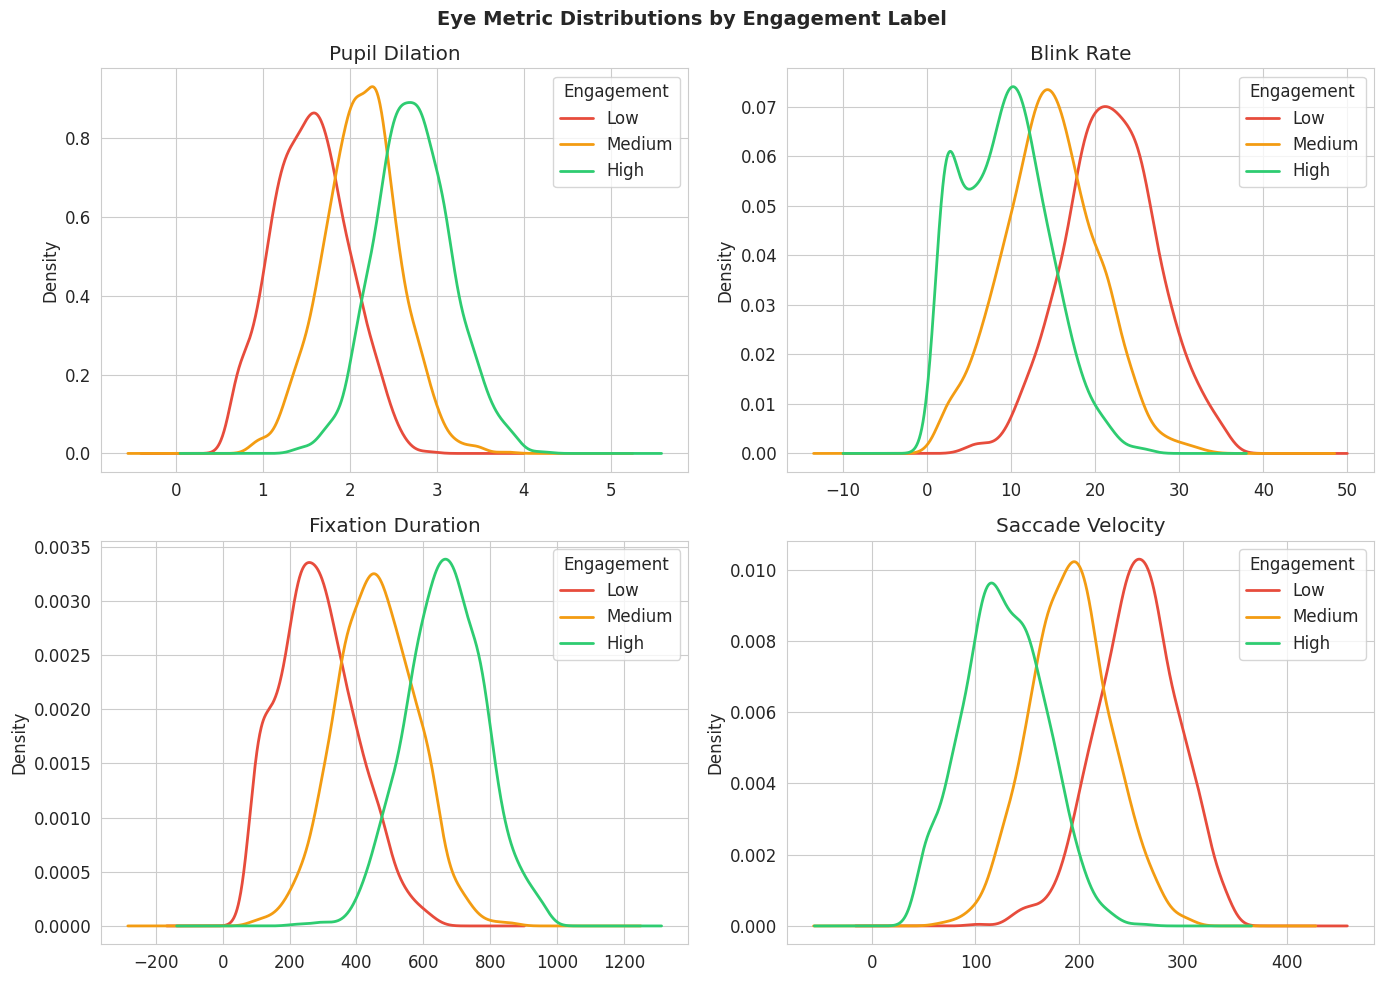

In [ ]:
# Define the four non-invasive eye-tracking features retained for modelling
eye_cols    = ['Pupil_Dilation', 'Blink_Rate', 'Fixation_Duration', 'Saccade_Velocity']
label_names = {0: 'Low', 1: 'Medium', 2: 'High'}
colors      = ['#e74c3c', '#f39c12', '#2ecc71']  # red=Low, amber=Medium, green=High

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), eye_cols):
    for label, color in zip([0, 1, 2], colors):
        subset = df[df['Engagement_Label'] == label][col]
        subset.plot.kde(ax=ax, label=label_names[label], color=color, linewidth=2)
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel(col.replace('_', ' '))
    ax.legend(title='Engagement Level')

plt.suptitle('KDE — Eye Metric Distributions by Engagement Label',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary: separated KDE curves confirm each feature carries discriminative
# information across engagement levels, validating feature retention.

### 3.2 Box Plots

Box plots reveal the median, interquartile range (IQR), and outliers per class.  
A systematic shift in medians across classes confirms monotonic feature-label relationships.

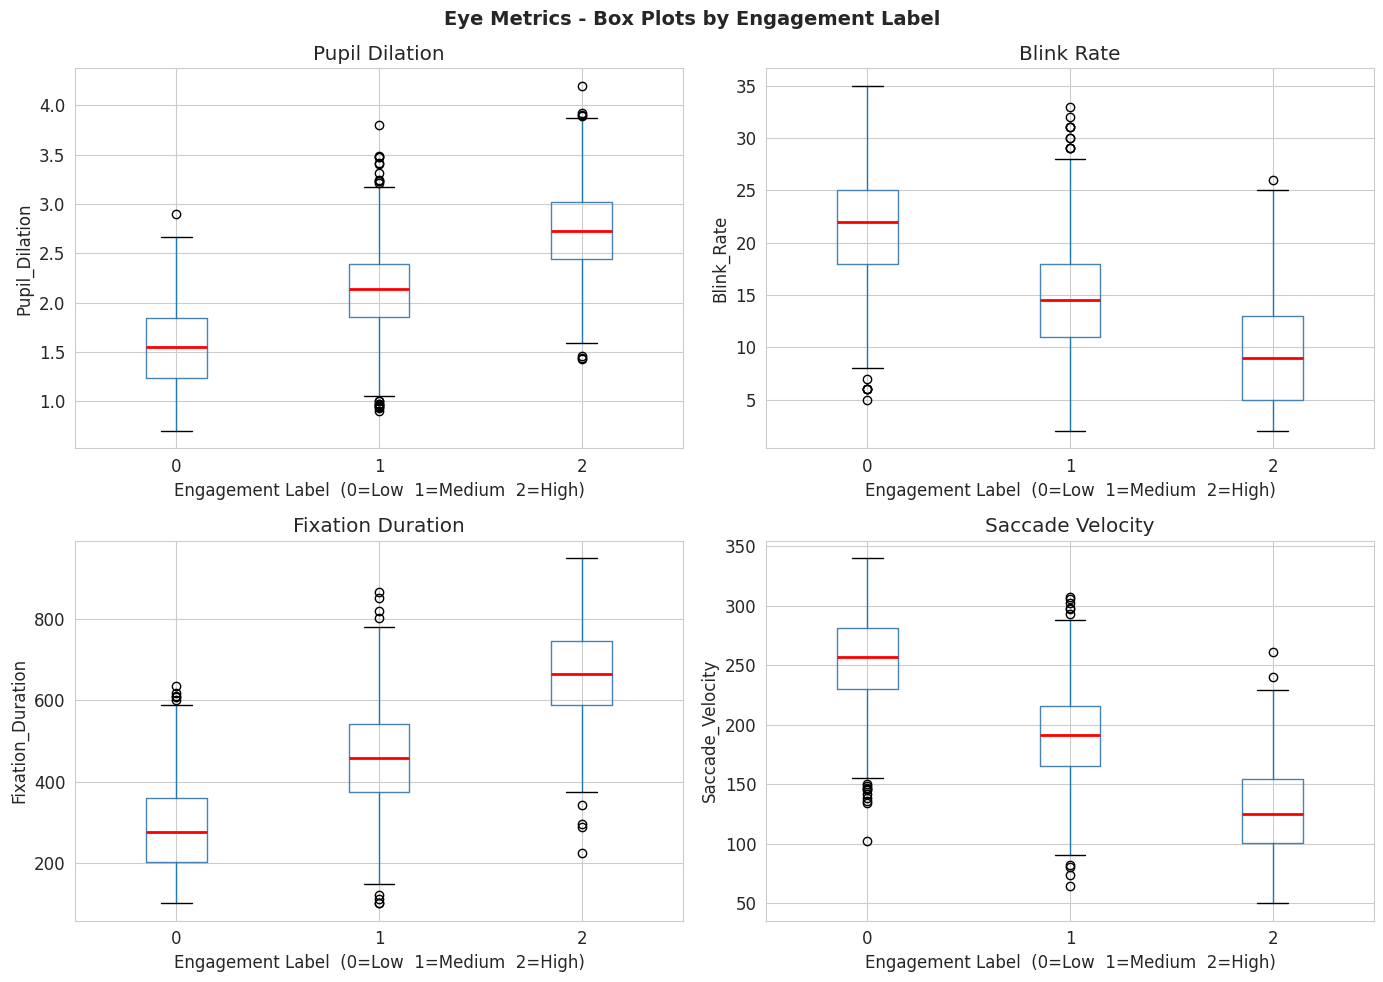

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), eye_cols):
    df.boxplot(column=col, by='Engagement_Label', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('Engagement Label  (0=Low  1=Medium  2=High)')
    ax.set_ylabel(col.replace('_', ' '))

plt.suptitle('Box Plots — Eye Metrics by Engagement Label',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

A Pearson correlation heatmap is computed over the full feature set  
(after label-encoding the two categorical variables).

**Objectives:**
- Identify which eye metrics are most strongly correlated with the target label
- Check for multicollinearity between features (high inter-feature correlation > 0.6  
  would indicate redundant features that could be removed)

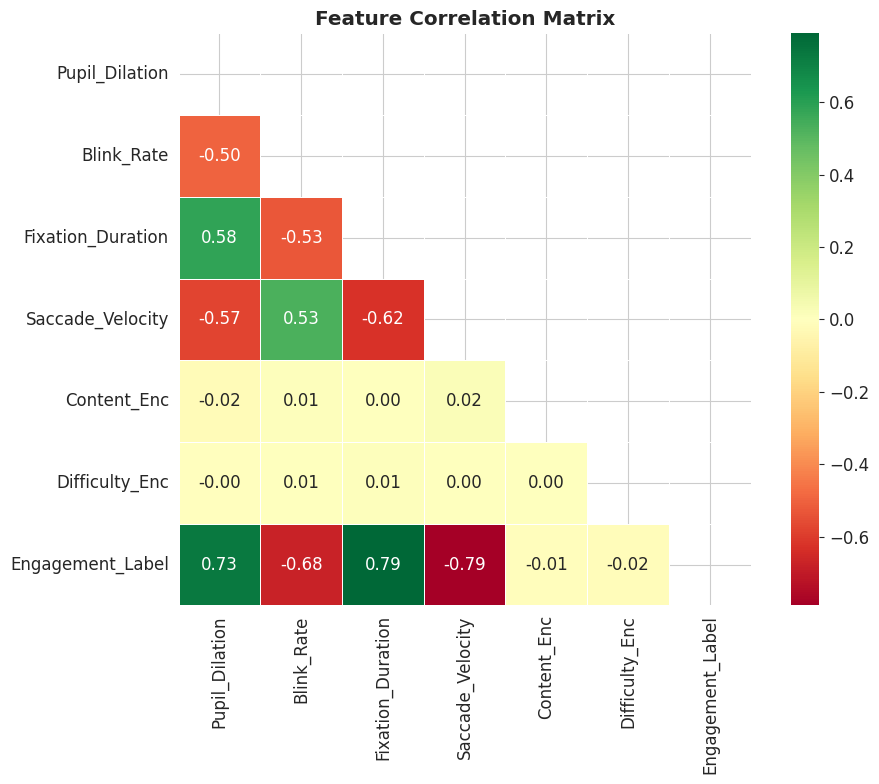

In [ ]:
# Label-encode categorical features for correlation computation only
# (these encoded columns are NOT used in the final model feature matrix)
le_content = LabelEncoder()
le_diff    = LabelEncoder()
df_enc = df.copy()
df_enc['Content_Enc']    = le_content.fit_transform(df['Learning_Content_Type'])
df_enc['Difficulty_Enc'] = le_diff.fit_transform(df['Difficulty_Level'])

# Build correlation matrix over all relevant columns including target
feat_cols = eye_cols + ['Content_Enc', 'Difficulty_Enc', 'Engagement_Label']
corr = df_enc[feat_cols].corr()

# Plot lower-triangle heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Matrix Construction


- Excluded (EEG):  Delta_PSD, Theta_PSD, Alpha_PSD, Beta_PSD, Gamma_PSD
- Excluded (ID):   Student_ID
- Excluded (cat):  Learning_Content_Type, Difficulty_Level
- Retained (eye):  Pupil_Dilation, Blink_Rate, Fixation_Duration, Saccade_Velocity

> **Rationale:** EEG requires specialist equipment and trained operators,  
> making it impractical for real-world classroom deployment. This research  
> aims to demonstrate that eye metrics alone are sufficient CL proxies.

In [ ]:
# Build feature matrix using only the four eye-tracking columns
feature_cols = eye_cols  # ['Pupil_Dilation','Blink_Rate','Fixation_Duration','Saccade_Velocity']
X = df_enc[feature_cols]  # feature matrix
y = df_enc['Engagement_Label']  # target vector (0=Low, 1=Medium, 2=High)

print('Feature columns:', feature_cols)
print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print()
print('Target class distribution:')
print(y.value_counts().sort_index().rename({0:'Low', 1:'Medium', 2:'High'}))

Feature columns: ['Pupil_Dilation', 'Blink_Rate', 'Fixation_Duration', 'Saccade_Velocity']
X shape: (3000, 4)  |  y shape: (3000,)
